# GO enrichment results, exploratory data analysis

Generic and species-agnostic. Every section below reads only from the
fixed output schema `enrichment.output.write_results()` always produces
(`go_id, class, population, observed, expected, fold_enrichment, p_value,
q_value, significance`), plus, optionally, an `.obo` file for GO term
names and a second results file for a full-GO vs GO-slim comparison.
Point the Configuration cell at any real run's output and everything
below works, regardless of species, metric, or labeling strategy.

Per the main README's language-constraint principle (section 4): results
at the p<0.01 uncorrected threshold should be read as genes that *tended
to include* a term, not as statistically significant findings.

In [1]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

RESULTS_ALL_TSV = "../results/GO/summary.CR_3D.PR_gene.all.tsv"

RESULTS_ALL_TSV_COMPARE = "../results/GO_slim/summary.CR_3D.PR_gene.all.tsv"
COMPARE_LABEL_PRIMARY = "full-GO"
COMPARE_LABEL_SECONDARY = "GO-slim"

OBO_PATH = "../data/go_reference/go-basic.obo"

SIG_COL = "p_value"
SIG_THRESH = 0.01

NEAR_MISS_MULTIPLIER = 3

TOP_N = 15

# How many significant terms per class to show in the bar plot below.
BAR_PLOT_TOP_N = 15

In [13]:
INPUT_TABLE = None
MERGE_MANIFEST = "merge_pr_gene_notebook.txt"
METRIC_COLS = ["cond_3D", "cond_6D"]

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(RESULTS_ALL_TSV, sep="\t", comment="#")
print(f"Loaded {len(df)} (class, GO term) rows from {RESULTS_ALL_TSV}")
print(f"Classes present: {sorted(df['class'].unique())}")

compare_df = None
if RESULTS_ALL_TSV_COMPARE:
    compare_df = pd.read_csv(RESULTS_ALL_TSV_COMPARE, sep="\t", comment="#")
    print(f"Loaded {len(compare_df)} rows from {RESULTS_ALL_TSV_COMPARE} for comparison")

df.head()

Loaded 2334 (class, GO term) rows from ../results/GO/summary.CR_3D.PR_gene.all.tsv
Classes present: ['High', 'Low']
Loaded 172 rows from ../results/GO_slim/summary.CR_3D.PR_gene.all.tsv for comparison


,go_id,class,population,observed,expected,fold_enrichment,p_value,q_value,significance
0,GO:0003824,High,229,16,21.490769,-0.403798,0.204256,1.0,False
1,GO:0003674,High,530,52,49.738462,0.062913,0.602251,1.0,False
2,GO:0016491,High,42,5,3.941538,0.280002,0.587833,1.0,False
3,GO:0005956,High,1,1,0.093846,0.870590,0.164339,1.0,False
4,GO:0019887,High,2,1,0.187692,0.751839,0.236237,1.0,False


## GO term names

In [3]:
godag = None
if OBO_PATH:
    from goatools.obo_parser import GODag
    godag = GODag(OBO_PATH)

def add_term_names(frame):
    frame = frame.copy()
    if godag is None:
        frame["go_name"] = frame["go_id"]
        frame["go_namespace"] = ""
        return frame
    frame["go_name"] = frame["go_id"].apply(
        lambda g: godag[g].name if g in godag else "(obsolete or not in this obo)"
    )
    frame["go_namespace"] = frame["go_id"].apply(
        lambda g: godag[g].namespace if g in godag else ""
    )
    return frame

df = add_term_names(df)
if compare_df is not None:
    compare_df = add_term_names(compare_df)

df.head()

../data/go_reference/go-basic.obo: fmt(1.2) rel(2026-07-26) 41,378 Terms


,go_id,class,population,observed,expected,fold_enrichment,p_value,q_value,significance,go_name,go_namespace
0,GO:0003824,High,229,16,21.490769,-0.403798,0.204256,1.0,False,catalytic activity,molecular_function
1,GO:0003674,High,530,52,49.738462,0.062913,0.602251,1.0,False,molecular_function,molecular_function
2,GO:0016491,High,42,5,3.941538,0.280002,0.587833,1.0,False,oxidoreductase activity,molecular_function
3,GO:0005956,High,1,1,0.093846,0.870590,0.164339,1.0,False,protein kinase CK2 complex,cellular_component
4,GO:0019887,High,2,1,0.187692,0.751839,0.236237,1.0,False,protein kinase regulator activity,molecular_function


## Summary counts per class

In [4]:
summary_rows = []
for cls, cls_df in df.groupby("class"):
    n_sig = int(cls_df["significance"].sum())
    n_over = int((cls_df["significance"] & (cls_df["fold_enrichment"] > 0)).sum())
    n_under = int((cls_df["significance"] & (cls_df["fold_enrichment"] < 0)).sum())
    summary_rows.append({
        "class": cls,
        "n_terms_tested": len(cls_df),
        "n_significant": n_sig,
        "n_over": n_over,
        "n_under": n_under,
        "min_p_value": cls_df["p_value"].min(),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

if summary_df["n_significant"].sum() == 0:
    print(
        "No significant terms in any class. Check the near-miss section below and "
        "the p-value distribution before concluding this is a real absence of signal."
    )

,class,n_terms_tested,n_significant,n_over,n_under,min_p_value
0,High,1167,3,2,1,0.006091
1,Low,1167,4,4,0,0.002497


## Top terms per class

In [5]:
display_cols = ["go_id", "go_name", "go_namespace", "population", "observed",
                 "expected", "fold_enrichment", "p_value", "q_value", "significance"]

for cls, cls_df in df.groupby("class"):
    print(f"\n--- class: {cls} ---")
    display(cls_df.sort_values("p_value").head(TOP_N)[display_cols])


--- class: High ---


,go_id,go_name,go_namespace,population,observed,expected,fold_enrichment,p_value,q_value,significance
89,GO:0046983,protein dimerization activity,molecular_function,15,6,1.407692,1.539704,0.006091,1.0,True
78,GO:0046982,protein heterodimerization activity,molecular_function,15,6,1.407692,1.539704,0.006091,1.0,True
75,GO:0008152,metabolic process,biological_process,211,10,19.801538,-0.919187,0.008938,1.0,True
73,GO:0044238,primary metabolic process,biological_process,192,9,18.018462,-0.927401,0.016517,1.0,False
115,GO:0030527,structural constituent of chromatin,molecular_function,14,5,1.313846,1.374670,0.017901,1.0,False
54,GO:0005694,chromosome,cellular_component,10,4,0.938462,1.367016,0.025548,1.0,False
217,GO:0061024,membrane organization,biological_process,2,2,0.187692,1.336801,0.038823,1.0,False
77,GO:0009987,cellular process,biological_process,301,20,28.247692,-0.477933,0.044337,1.0,False
94,GO:0000785,chromatin,cellular_component,7,3,0.656923,1.271493,0.046666,1.0,False
37,GO:0005515,protein binding,molecular_function,129,19,12.106154,0.609756,0.047000,1.0,False



--- class: Low ---


,go_id,go_name,go_namespace,population,observed,expected,fold_enrichment,p_value,q_value,significance
1330,GO:0016043,cellular component organization,biological_process,25,9,2.576923,1.483209,0.002497,1.0,True
1411,GO:0022607,cellular component assembly,biological_process,16,7,1.649231,1.594426,0.003328,1.0,True
1349,GO:0071840,cellular component organization or biogenesis,biological_process,34,10,3.504615,1.288028,0.004866,1.0,True
1413,GO:0044085,cellular component biogenesis,biological_process,25,8,2.576923,1.331206,0.007939,1.0,True
1426,GO:0006412,translation,biological_process,49,0,5.050769,-2.597119,0.010276,1.0,False
1425,GO:0160307,protein biosynthetic process,biological_process,49,0,5.050769,-2.597119,0.010276,1.0,False
1550,GO:0022618,protein-RNA complex assembly,biological_process,4,3,0.412308,1.501946,0.020781,1.0,False
1555,GO:0071826,protein-RNA complex organization,biological_process,4,3,0.412308,1.501946,0.020781,1.0,False
1408,GO:0065003,protein-containing complex assembly,biological_process,14,5,1.443077,1.296263,0.025342,1.0,False
1414,GO:0043933,protein-containing complex organization,biological_process,14,5,1.443077,1.296263,0.025342,1.0,False


## Significant terms, bar plot

The table above shows the same information, this is a visual alternative:
one horizontal bar per significant term, sorted by strength, x-axis is
`-log10(p_value)` (taller bar = stronger signal), colored by direction
(over- vs under-represented). Only actually significant terms are shown
here (unlike the table above, which includes near-misses) -- if a class
has none, that is stated plainly rather than showing an empty plot.

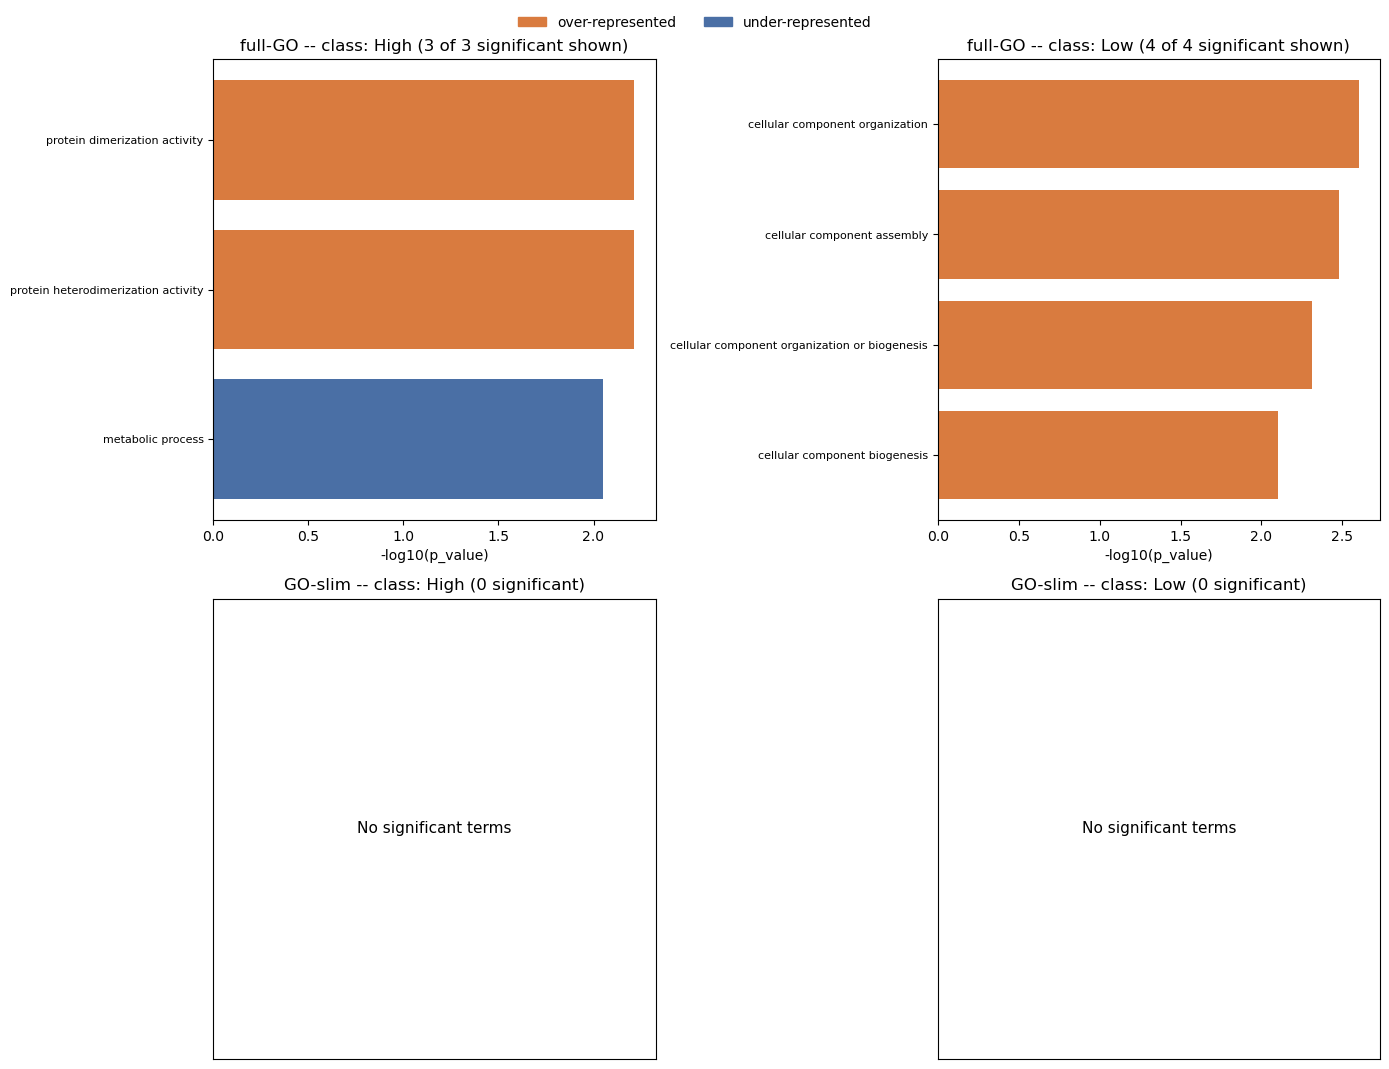

In [6]:
classes = sorted(df["class"].unique())

# Show BOTH full-GO (primary) and GO-slim (secondary), if a comparison
# file was given -- not just one of them, matching every other section
# in this notebook that treats the two as a real, load-bearing pair.
sources_to_plot = [(COMPARE_LABEL_PRIMARY, df)]
if compare_df is not None:
    sources_to_plot.append((COMPARE_LABEL_SECONDARY, compare_df))

n_rows = len(sources_to_plot)
n_cols = len(classes)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(7 * n_cols, max(4, BAR_PLOT_TOP_N * 0.35) * n_rows),
    squeeze=False,
)

for row_idx, (label, source_df) in enumerate(sources_to_plot):
    for col_idx, cls in enumerate(classes):
        ax = axes[row_idx][col_idx]
        cls_all = source_df[source_df["class"] == cls]
        cls_sig = cls_all[cls_all["significance"]].copy()

        if len(cls_sig) == 0:
            ax.text(0.5, 0.5, "No significant terms", ha="center", va="center", fontsize=11)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"{label} -- class: {cls} (0 significant)")
            continue

        cls_sig["neg_log10_p"] = -np.log10(cls_sig["p_value"].clip(lower=1e-300))
        n_sig_total = len(cls_sig)
        cls_sig = cls_sig.sort_values("neg_log10_p").tail(BAR_PLOT_TOP_N)
        colors = np.where(cls_sig["fold_enrichment"] > 0, "#D97B3F", "#4A6FA5")

        ax.barh(cls_sig["go_name"], cls_sig["neg_log10_p"], color=colors)
        ax.set_xlabel("-log10(p_value)")
        shown = min(BAR_PLOT_TOP_N, n_sig_total)
        ax.set_title(f"{label} -- class: {cls} ({shown} of {n_sig_total} significant shown)")
        ax.tick_params(axis="y", labelsize=8)

from matplotlib.patches import Patch
legend_handles = [Patch(color="#D97B3F", label="over-represented"),
                  Patch(color="#4A6FA5", label="under-represented")]
fig.legend(handles=legend_handles, loc="upper center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

## Near-miss terms

In [7]:
near_miss_upper = SIG_THRESH * NEAR_MISS_MULTIPLIER
near_miss = df[
    (~df["significance"])
    & (df[SIG_COL] >= SIG_THRESH)
    & (df[SIG_COL] <= near_miss_upper)
].sort_values(SIG_COL)

print(f"{len(near_miss)} near-miss terms "
      f"({SIG_THRESH} <= {SIG_COL} <= {near_miss_upper}, not already significant)")
display(near_miss[["class"] + display_cols])

10 near-miss terms (0.01 <= p_value <= 0.03, not already significant)


,class,go_id,go_name,go_namespace,population,observed,expected,fold_enrichment,p_value,q_value,significance
1426,Low,GO:0006412,translation,biological_process,49,0,5.050769,-2.597119,0.010276,1.0,False
1425,Low,GO:0160307,protein biosynthetic process,biological_process,49,0,5.050769,-2.597119,0.010276,1.0,False
73,High,GO:0044238,primary metabolic process,biological_process,192,9,18.018462,-0.927401,0.016517,1.0,False
115,High,GO:0030527,structural constituent of chromatin,molecular_function,14,5,1.313846,1.374670,0.017901,1.0,False
1555,Low,GO:0071826,protein-RNA complex organization,biological_process,4,3,0.412308,1.501946,0.020781,1.0,False
1550,Low,GO:0022618,protein-RNA complex assembly,biological_process,4,3,0.412308,1.501946,0.020781,1.0,False
1414,Low,GO:0043933,protein-containing complex organization,biological_process,14,5,1.443077,1.296263,0.025342,1.0,False
1408,Low,GO:0065003,protein-containing complex assembly,biological_process,14,5,1.443077,1.296263,0.025342,1.0,False
1528,Low,GO:0022613,ribonucleoprotein complex biogenesis,biological_process,14,5,1.443077,1.296263,0.025342,1.0,False
54,High,GO:0005694,chromosome,cellular_component,10,4,0.938462,1.367016,0.025548,1.0,False


## Volcano-style plot

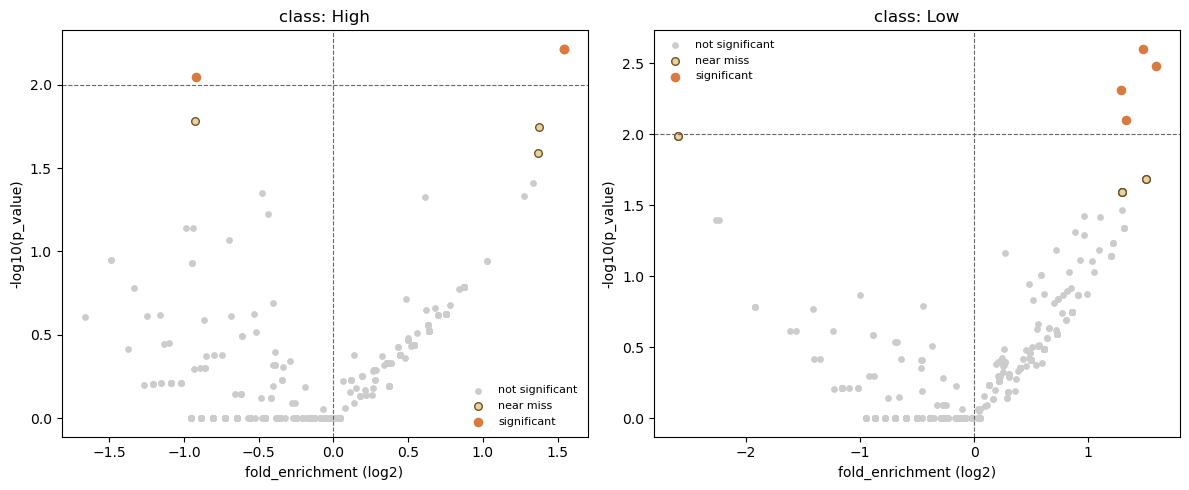

In [8]:
fig, axes = plt.subplots(1, len(classes), figsize=(6 * len(classes), 5), squeeze=False)
axes = axes[0]

for ax, cls in zip(axes, classes):
    cls_df = df[df["class"] == cls].copy()
    cls_df["neg_log10_p"] = -np.log10(cls_df["p_value"].clip(lower=1e-300))

    is_near_miss = (
        (~cls_df["significance"])
        & (cls_df[SIG_COL] >= SIG_THRESH)
        & (cls_df[SIG_COL] <= near_miss_upper)
    )
    not_sig = cls_df[~cls_df["significance"] & ~is_near_miss]
    near = cls_df[is_near_miss]
    sig = cls_df[cls_df["significance"]]

    ax.scatter(not_sig["fold_enrichment"], not_sig["neg_log10_p"],
               color="0.8", s=15, label="not significant", zorder=1)
    ax.scatter(near["fold_enrichment"], near["neg_log10_p"],
               color="#E8D3A0", edgecolor="#6B5527", s=30, label="near miss", zorder=2)
    ax.scatter(sig["fold_enrichment"], sig["neg_log10_p"],
               color="#D97B3F", s=35, label="significant", zorder=3)

    ax.axhline(-np.log10(SIG_THRESH), color="0.4", linestyle="--", linewidth=0.8)
    ax.axvline(0, color="0.4", linestyle="--", linewidth=0.8)
    ax.set_xlabel("fold_enrichment (log2)")
    ax.set_ylabel("-log10(p_value)")
    ax.set_title(f"class: {cls}")
    ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

## Observed vs expected

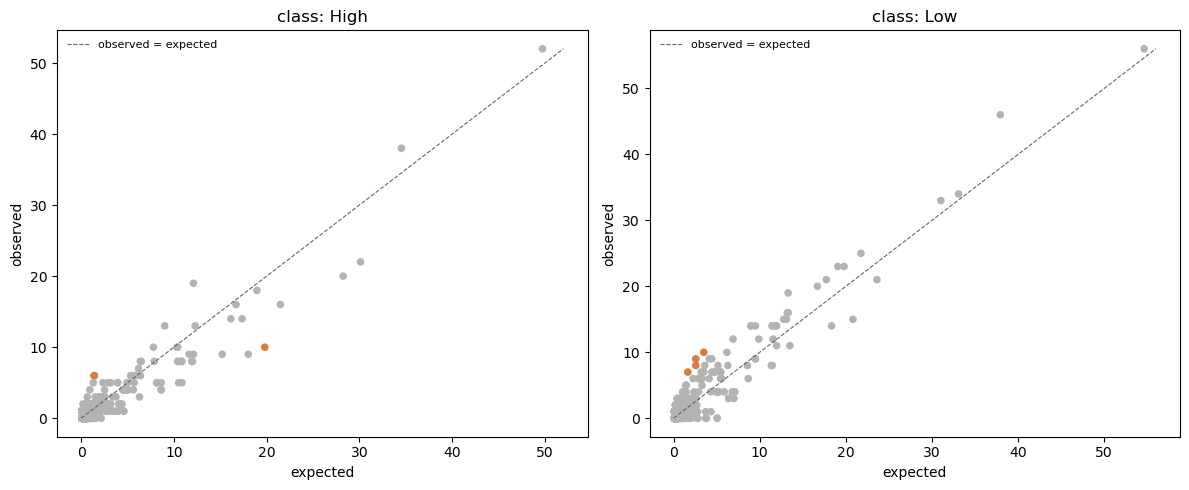

In [9]:
fig, axes = plt.subplots(1, len(classes), figsize=(6 * len(classes), 5), squeeze=False)
axes = axes[0]

for ax, cls in zip(axes, classes):
    cls_df = df[df["class"] == cls]
    colors = np.where(cls_df["significance"], "#D97B3F", "0.7")
    ax.scatter(cls_df["expected"], cls_df["observed"], c=colors, s=20)
    max_val = max(cls_df["expected"].max(), cls_df["observed"].max())
    ax.plot([0, max_val], [0, max_val], color="0.4", linestyle="--", linewidth=0.8,
            label="observed = expected")
    ax.set_xlabel("expected")
    ax.set_ylabel("observed")
    ax.set_title(f"class: {cls}")
    ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

## p-value distribution

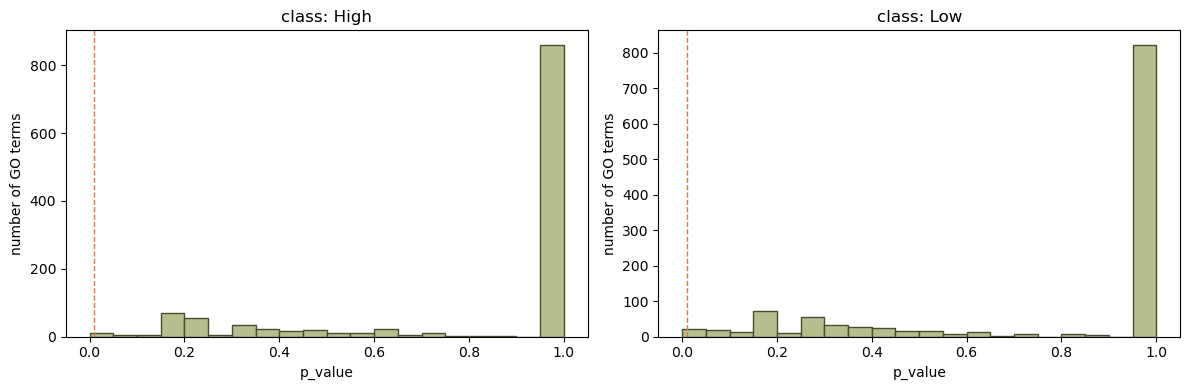

In [10]:
fig, axes = plt.subplots(1, len(classes), figsize=(6 * len(classes), 4), squeeze=False)
axes = axes[0]

for ax, cls in zip(axes, classes):
    cls_df = df[df["class"] == cls]
    ax.hist(cls_df["p_value"], bins=20, range=(0, 1), color="#B7BE8D", edgecolor="#4A4D2E")
    ax.axvline(SIG_THRESH, color="#D97B3F", linestyle="--", linewidth=1)
    ax.set_xlabel("p_value")
    ax.set_ylabel("number of GO terms")
    ax.set_title(f"class: {cls}")

fig.tight_layout()
plt.show()

## Comparison against a second run

172 (class, go_id) pairs present in both full-GO (2334 rows) and GO-slim (172 rows)


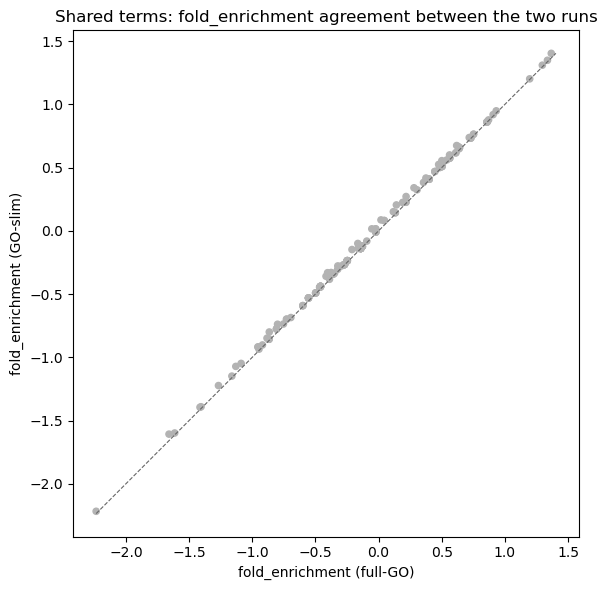


Significant in full-GO only: 0

Significant in GO-slim only: 0


In [11]:
if compare_df is not None:
    merged = df.merge(
        compare_df, on=["go_id", "class"], suffixes=("_primary", "_secondary"), how="inner"
    )
    print(f"{len(merged)} (class, go_id) pairs present in both "
          f"{COMPARE_LABEL_PRIMARY} ({len(df)} rows) and "
          f"{COMPARE_LABEL_SECONDARY} ({len(compare_df)} rows)")

    fig, ax = plt.subplots(figsize=(6, 6))
    colors = np.where(
        merged["significance_primary"] | merged["significance_secondary"],
        "#D97B3F", "0.7"
    )
    ax.scatter(merged["fold_enrichment_primary"], merged["fold_enrichment_secondary"],
               c=colors, s=20)
    lims = [
        min(merged["fold_enrichment_primary"].min(), merged["fold_enrichment_secondary"].min()),
        max(merged["fold_enrichment_primary"].max(), merged["fold_enrichment_secondary"].max()),
    ]
    ax.plot(lims, lims, color="0.4", linestyle="--", linewidth=0.8)
    ax.set_xlabel(f"fold_enrichment ({COMPARE_LABEL_PRIMARY})")
    ax.set_ylabel(f"fold_enrichment ({COMPARE_LABEL_SECONDARY})")
    ax.set_title("Shared terms: fold_enrichment agreement between the two runs")
    fig.tight_layout()
    plt.show()

    only_primary_sig = merged[merged["significance_primary"] & ~merged["significance_secondary"]]
    only_secondary_sig = merged[merged["significance_secondary"] & ~merged["significance_primary"]]
    print(f"\nSignificant in {COMPARE_LABEL_PRIMARY} only: {len(only_primary_sig)}")
    if len(only_primary_sig):
        display(only_primary_sig[["class", "go_id", "go_name_primary",
                                    "p_value_primary", "p_value_secondary"]])
    print(f"\nSignificant in {COMPARE_LABEL_SECONDARY} only: {len(only_secondary_sig)}")
    if len(only_secondary_sig):
        display(only_secondary_sig[["class", "go_id", "go_name_primary",
                                      "p_value_primary", "p_value_secondary"]])
else:
    print("RESULTS_ALL_TSV_COMPARE is not set, skipping comparison section.")

## Auto-generated plain-language summary

In [12]:
for cls, cls_df in df.groupby("class"):
    sig_over = cls_df[cls_df["significance"] & (cls_df["fold_enrichment"] > 0)].sort_values("p_value")
    sig_under = cls_df[cls_df["significance"] & (cls_df["fold_enrichment"] < 0)].sort_values("p_value")

    print(f"Class '{cls}' ({len(cls_df)} terms tested):")
    if len(sig_over):
        names = ", ".join(sig_over["go_name"].head(5))
        print(f"  Genes in this class tended to include: {names}"
              f"{' (and others)' if len(sig_over) > 5 else ''}.")
    if len(sig_under):
        names = ", ".join(sig_under["go_name"].head(5))
        print(f"  Genes in this class tended to under-represent: {names}"
              f"{' (and others)' if len(sig_under) > 5 else ''}.")
    if not len(sig_over) and not len(sig_under):
        print(f"  No terms reached the significance threshold for this class.")
    print()

Class 'High' (1167 terms tested):
  Genes in this class tended to include: protein heterodimerization activity, protein dimerization activity.
  Genes in this class tended to under-represent: metabolic process.

Class 'Low' (1167 terms tested):
  Genes in this class tended to include: cellular component organization, cellular component assembly, cellular component organization or biogenesis, cellular component biogenesis.



## Next steps

This notebook is exploration only, it never writes anything to disk. For
any GO ID, the full definition can be looked up at
https://amigo.geneontology.org/amigo/term/<go_id>.